In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd
import random

import nltk
from nltk.corpus import wordnet
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df = pd.read_csv(
    'WELFake_Dataset.csv',
    encoding='utf-8',
    on_bad_lines='skip',
    engine='python'
)

df = df[['text', 'label']].dropna()

print(df.shape)
print(df['label'].value_counts())

In [ ]:
df['label'] = pd.to_numeric(df['label'], errors='coerce')
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)

In [ ]:
print(df['label'].unique())


In [ ]:
samples_per_class = min(3000, df['label'].value_counts().min())

df_small = df.groupby('label', group_keys=False).apply(
    lambda x: x.sample(samples_per_class)
)

print(df_small['label'].value_counts())

In [ ]:
# uloženie pôvodného skrateného datasetu
df_small.to_csv('WELFake_original_small.csv', index=False, encoding='utf-8')
print("Pôvodný skratený dataset uložený ako WELFake_original_small.csv")


In [ ]:

df = pd.read_csv(
    'WELFake_original_small.csv',
    encoding='utf-8',
    on_bad_lines='skip',
    engine='python'
)

df = df[['text', 'label']].dropna()

print(df.shape)
print(df['label'].value_counts())

(6000, 2)
label
0    3000
1    3000
Name: count, dtype: int64


In [ ]:
import re

def clean_text(text):
    # odstráni HTML tagy
    text = re.sub(r'<.*?>', ' ', text)

    # odstráni len špeciálne znaky (NECHÁ písmená, čísla a interpunkciu)
    text = re.sub(r'[^a-zA-Z0-9\s\.\!\?]', ' ', text)

    # viacnásobné medzery → jedna
    text = re.sub(r'\s+', ' ', text)

    return text.strip().lower()

In [ ]:
import pandas as pd

# odstránenie NaN
df = df.dropna(subset=['text'])

# odstránenie prázdnych stringov
df = df[df['text'].str.strip() != '']

# zabezpečenie string typu
df['text'] = df['text'].astype(str)

# aplikovanie clean_text
df['text'] = df['text'].apply(clean_text)

In [ ]:
samples_per_class = min(500, df['label'].value_counts().min())

df_small = df.groupby('label', group_keys=False).apply(
    lambda x: x.sample(samples_per_class)
)

print(df_small['label'].value_counts())

label
0    500
1    500
Name: count, dtype: int64


/tmp/ipykernel_2766/3911056418.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_small = df.groupby('label', group_keys=False).apply(


In [ ]:
df.to_csv('WELFake_original_small_1.csv', index=False, encoding='utf-8')
print("Pôvodný skratený dataset uložený")

Pôvodný skratený dataset uložený ako WELFake_original_small.csv


In [ ]:
# uloženie pôvodného skrateného datasetu
df_small.to_csv('WELFake_original_small_2.csv', index=False, encoding='utf-8')
print("Pôvodný skratený dataset uložený ako WELFake_original_small.csv")



Pôvodný skratený dataset uložený ako WELFake_original_small.csv


In [ ]:
df_small = pd.read_csv(
    'WELFake_original_small_2.csv',
    encoding='utf-8',
    on_bad_lines='skip',
    engine='python'
)


**Bez augmentacie**

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

nb_scores = {"acc": [], "prec": [], "rec": [], "f1": []}
lr_scores = {"acc": [], "prec": [], "rec": [], "f1": []}

for fold, (train_idx, test_idx) in enumerate(kf.split(df, df['label'])):
    print(f"\nFold {fold+1}")
    random.seed(42 + fold)
    np.random.seed(42 + fold)

    train_df = df.iloc[train_idx].copy()
    test_df = df.iloc[test_idx].copy()

    # 🔹 TF-IDF (bez augmentácie)
    vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')

    X_train = vectorizer.fit_transform(train_df['text'])
    y_train = train_df['label'].astype(int)

    X_test = vectorizer.transform(test_df['text'])
    y_test = test_df['label'].astype(int)

    # 🔹 MODELY
    nb = MultinomialNB()
    lr = LogisticRegression(max_iter=1000)

    nb.fit(X_train, y_train)
    lr.fit(X_train, y_train)

    y_pred_nb = nb.predict(X_test)
    y_pred_lr = lr.predict(X_test)

    # 🔹 METRIKY
    def compute_metrics(y_true, y_pred):
        return {
            "acc": accuracy_score(y_true, y_pred),
            "prec": precision_score(y_true, y_pred, average='weighted', zero_division=0),
            "rec": recall_score(y_true, y_pred, average='weighted', zero_division=0),
            "f1": f1_score(y_true, y_pred, average='weighted', zero_division=0),
        }

    nb_m = compute_metrics(y_test, y_pred_nb)
    lr_m = compute_metrics(y_test, y_pred_lr)

    for k in nb_scores:
        nb_scores[k].append(nb_m[k])
        lr_scores[k].append(lr_m[k])

# 🔹 VÝSLEDKY
print("\nNaive Bayes (bez augmentácie):")
for k in nb_scores:
    print(f"{k.upper()}: {nb_scores[k]}")
    print(f"Average {k.upper()}: {np.mean(nb_scores[k])}")

print("\nLogistic Regression (bez augmentácie):")
for k in lr_scores:
    print(f"{k.upper()}: {lr_scores[k]}")
    print(f"Average {k.upper()}: {np.mean(lr_scores[k])}")


Fold 1

Fold 2

Fold 3

Fold 4

Fold 5

Naive Bayes (bez augmentácie):
ACC: [0.8264532434709352, 0.8348778433024431, 0.8171861836562764, 0.851602023608769, 0.8406408094435076]
Average ACC: 0.8341520206963862
PREC: [0.8268882328924461, 0.8354991173243875, 0.8171904580023801, 0.8518393870852015, 0.8411348965560842]
Average PREC: 0.8345104183720998
REC: [0.8264532434709352, 0.8348778433024431, 0.8171861836562764, 0.851602023608769, 0.8406408094435076]
Average REC: 0.8341520206963862
F1: [0.8264359986693041, 0.834846901533446, 0.8171877408161764, 0.851602023608769, 0.8406241546136214]
Average F1: 0.8341393638482634

Logistic Regression (bez augmentácie):
ACC: [0.8854254422914911, 0.9005897219882055, 0.8736310025273799, 0.8988195615514334, 0.9005059021922428]
Average ACC: 0.8917943261101506
PREC: [0.886001944913128, 0.9021334599205151, 0.8736310025273799, 0.898908259785157, 0.9011011004363111]
Average PREC: 0.8923551535164982
REC: [0.8854254422914911, 0.9005897219882055, 0.8736310025273799

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

nb_scores = {"acc": [], "prec": [], "rec": [], "f1": []}
lr_scores = {"acc": [], "prec": [], "rec": [], "f1": []}

for fold, (train_idx, test_idx) in enumerate(kf.split(df_small, df_small['label'])):
    print(f"\nFold {fold+1}")
    random.seed(42 + fold)
    np.random.seed(42 + fold)

    train_df = df_small.iloc[train_idx].copy()
    test_df = df_small.iloc[test_idx].copy()

    # 🔹 TF-IDF (bez augmentácie)
    vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')

    X_train = vectorizer.fit_transform(train_df['text'])
    y_train = train_df['label'].astype(int)

    X_test = vectorizer.transform(test_df['text'])
    y_test = test_df['label'].astype(int)

    # 🔹 MODELY
    nb = MultinomialNB()
    lr = LogisticRegression(max_iter=1000)

    nb.fit(X_train, y_train)
    lr.fit(X_train, y_train)

    y_pred_nb = nb.predict(X_test)
    y_pred_lr = lr.predict(X_test)

    # 🔹 METRIKY
    def compute_metrics(y_true, y_pred):
        return {
            "acc": accuracy_score(y_true, y_pred),
            "prec": precision_score(y_true, y_pred, average='weighted', zero_division=0),
            "rec": recall_score(y_true, y_pred, average='weighted', zero_division=0),
            "f1": f1_score(y_true, y_pred, average='weighted', zero_division=0),
        }

    nb_m = compute_metrics(y_test, y_pred_nb)
    lr_m = compute_metrics(y_test, y_pred_lr)

    for k in nb_scores:
        nb_scores[k].append(nb_m[k])
        lr_scores[k].append(lr_m[k])

# 🔹 VÝSLEDKY
print("\nNaive Bayes (bez augmentácie):")
for k in nb_scores:
    print(f"{k.upper()}: {nb_scores[k]}")
    print(f"Average {k.upper()}: {np.mean(nb_scores[k])}")

print("\nLogistic Regression (bez augmentácie):")
for k in lr_scores:
    print(f"{k.upper()}: {lr_scores[k]}")
    print(f"Average {k.upper()}: {np.mean(lr_scores[k])}")


Fold 1

Fold 2

Fold 3

Fold 4

Fold 5

Naive Bayes (bez augmentácie):
ACC: [0.815, 0.835, 0.81, 0.83, 0.83]
Average ACC: 0.8240000000000001
PREC: [0.8152837553798418, 0.835301771594435, 0.8111200321156161, 0.8311922922521076, 0.8305288461538461]
Average PREC: 0.8246853394991692
REC: [0.815, 0.835, 0.81, 0.83, 0.83]
Average REC: 0.8240000000000001
F1: [0.8149583656322673, 0.8349628666449951, 0.8098288459613653, 0.8298468621759583, 0.8299319727891157]
Average F1: 0.8239057826407403

Logistic Regression (bez augmentácie):
ACC: [0.855, 0.85, 0.81, 0.855, 0.87]
Average ACC: 0.8480000000000001
PREC: [0.855035503550355, 0.850140056022409, 0.810124049619848, 0.8567480655210531, 0.8713368125250903]
Average PREC: 0.8486768974477512
REC: [0.855, 0.85, 0.81, 0.855, 0.87]
Average REC: 0.8480000000000001
F1: [0.8549963749093727, 0.84998499849985, 0.80998099809981, 0.8548221571424997, 0.8698828946051447]
Average F1: 0.8479334846513353


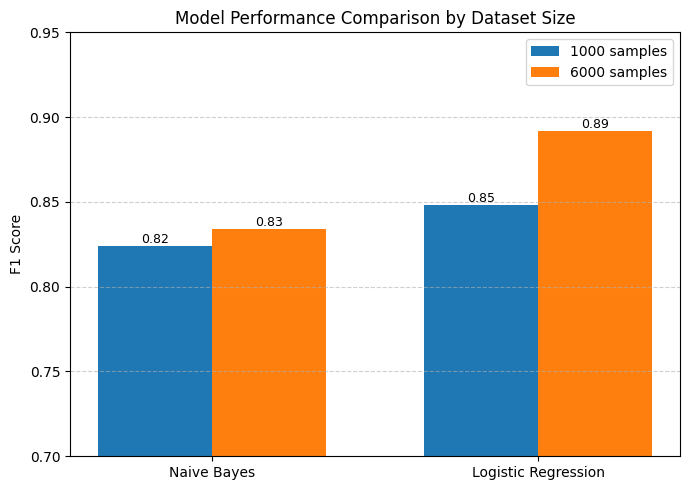

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Naive Bayes','Logistic Regression']

f1_6000 = [0.8341, 0.8917]
f1_1000 = [0.8239, 0.8479]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(7,5))

bars1 = plt.bar(x - width/2, f1_1000, width, label='1000 samples')
bars2 = plt.bar(x + width/2, f1_6000, width, label='6000 samples')

# hodnoty nad stĺpcami
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height,
                 f'{height:.2f}',
                 ha='center', va='bottom', fontsize=9)

plt.xticks(x, models)
plt.ylabel("F1 Score")
plt.title("Model Performance Comparison by Dataset Size")
plt.legend()

plt.ylim(0.7, 0.95)  # lepšie škálovanie pre F1

# jemná mriežka
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

**Random Inserion**

In [ ]:


# získa synonymá
def get_synonyms(word):
    synonyms = set()
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            synonyms.add(lemma.name())
    return list(synonyms)

# vloženie synonyma do zoznamu slov
def random_insertion(words, n=1):
    new_words = words.copy()

    for _ in range(n):
        if len(words) == 0:
            break

        random_word = random.choice(words)
        synonyms = get_synonyms(random_word)

        if len(synonyms) > 0:
            synonym = random.choice(synonyms)
            insert_pos = random.randint(0, len(new_words))
            new_words.insert(insert_pos, synonym)

    return new_words

# 🔹 UPRAVENÁ VERZIA – po vetách
def eda_random_insertion(text):
    if not isinstance(text, str):
        return ""

    # rozdelenie na vety (zachováme . ! ?)
    import re
    sentences = re.split(r'([.!?])', text)

    new_sentences = []

    # spojenie viet + interpunkcie
    for i in range(0, len(sentences)-1, 2):
        sentence = sentences[i]
        punct = sentences[i+1]

        words = sentence.split()

        if len(words) == 0:
            new_sentences.append(sentence + punct)
            continue

        new_words = random_insertion(words, n=2)

        new_sentences.append(" ".join(new_words) + punct)

    return " ".join(new_sentences)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np


kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42, )

nb_scores = {"acc": [], "prec": [], "rec": [], "f1": []}
lr_scores = {"acc": [], "prec": [], "rec": [], "f1": []}

for fold, (train_idx, test_idx) in enumerate(kf.split(df_small, df_small['label'])):
    print(f"\nFold {fold+1}")
    random.seed(42 + fold)
    np.random.seed(42 + fold)
    train_df = df_small.iloc[train_idx].copy()
    test_df = df_small.iloc[test_idx].copy()

    # 🔹 AUGMENTÁCIA LEN TRAIN
    sample_size = int(0.5 * len(train_df))
    aug_df = train_df.sample(sample_size, replace=True, random_state=42).copy()
    aug_df['text'] = aug_df['text'].apply(eda_random_insertion)

    train_aug = pd.concat([train_df, aug_df])

    # 🔹 TF-IDF
    vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')

    X_train = vectorizer.fit_transform(train_aug['text'])
    y_train = train_aug['label'].astype(int)

    X_test = vectorizer.transform(test_df['text'])
    y_test = test_df['label'].astype(int)

    # 🔹 MODELY
    nb = MultinomialNB()
    lr = LogisticRegression(max_iter=1000)

    nb.fit(X_train, y_train)
    lr.fit(X_train, y_train)

    y_pred_nb = nb.predict(X_test)
    y_pred_lr = lr.predict(X_test)

    # 🔹 METRIKY
    def compute_metrics(y_true, y_pred):
        return {
            "acc": accuracy_score(y_true, y_pred),
            "prec": precision_score(y_true, y_pred, average='weighted', zero_division=0),
            "rec": recall_score(y_true, y_pred, average='weighted', zero_division=0),
            "f1": f1_score(y_true, y_pred, average='weighted', zero_division=0),
        }

    nb_m = compute_metrics(y_test, y_pred_nb)
    lr_m = compute_metrics(y_test, y_pred_lr)

    for k in nb_scores:
        nb_scores[k].append(nb_m[k])
        lr_scores[k].append(lr_m[k])

# 🔹 VÝSLEDKY
print("\nNaive Bayes:")
for k in nb_scores:
    print(f"{k.upper()}: {nb_scores[k]}")
    print(f"Average {k.upper()}: {np.mean(nb_scores[k])}")

print("\nLogistic Regression:")
for k in lr_scores:
    print(f"{k.upper()}: {lr_scores[k]}")
    print(f"Average {k.upper()}: {np.mean(lr_scores[k])}")


Fold 1

Fold 2

Fold 3

Fold 4

Fold 5

Naive Bayes:
ACC: [0.795, 0.84, 0.82, 0.815, 0.815]
Average ACC: 0.817
PREC: [0.7950295029502951, 0.84, 0.8205128205128206, 0.8157894736842105, 0.8165511003919204]
Average PREC: 0.8175765795078493
REC: [0.795, 0.84, 0.82, 0.815, 0.815]
Average REC: 0.817
F1: [0.7949948748718718, 0.84, 0.8199279711884754, 0.8148843026891808, 0.8147730970438788]
Average F1: 0.8169160491586812

Logistic Regression:
ACC: [0.855, 0.865, 0.815, 0.865, 0.87]
Average ACC: 0.8540000000000001
PREC: [0.855035503550355, 0.8650365036503651, 0.8150315031503151, 0.8667973068033363, 0.8713368125250903]
Average PREC: 0.8546475259358923
REC: [0.855, 0.865, 0.815, 0.865, 0.87]
Average REC: 0.8540000000000001
F1: [0.8549963749093727, 0.8649966249156228, 0.8149953748843721, 0.8648344221671548, 0.8698828946051447]
Average F1: 0.8539411382963333


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np


kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

nb_scores = {"acc": [], "prec": [], "rec": [], "f1": []}
lr_scores = {"acc": [], "prec": [], "rec": [], "f1": []}

for fold, (train_idx, test_idx) in enumerate(kf.split(df_small, df_small['label'])):
    print(f"\nFold {fold+1}")
    random.seed(42 + fold)
    np.random.seed(42 + fold)
    train_df = df_small.iloc[train_idx].copy()
    test_df = df_small.iloc[test_idx].copy()

    # 🔹 AUGMENTÁCIA LEN TRAIN
    sample_size = int(1 * len(train_df))
    aug_df = train_df.sample(sample_size, replace=True, random_state=42).copy()
    aug_df['text'] = aug_df['text'].apply(eda_random_insertion)

    train_aug = pd.concat([train_df, aug_df])

    # 🔹 TF-IDF
    vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')

    X_train = vectorizer.fit_transform(train_aug['text'])
    y_train = train_aug['label'].astype(int)

    X_test = vectorizer.transform(test_df['text'])
    y_test = test_df['label'].astype(int)

    # 🔹 MODELY
    nb = MultinomialNB()
    lr = LogisticRegression(max_iter=1000)

    nb.fit(X_train, y_train)
    lr.fit(X_train, y_train)

    y_pred_nb = nb.predict(X_test)
    y_pred_lr = lr.predict(X_test)

    # 🔹 METRIKY
    def compute_metrics(y_true, y_pred):
        return {
            "acc": accuracy_score(y_true, y_pred),
            "prec": precision_score(y_true, y_pred, average='weighted', zero_division=0),
            "rec": recall_score(y_true, y_pred, average='weighted', zero_division=0),
            "f1": f1_score(y_true, y_pred, average='weighted', zero_division=0),
        }

    nb_m = compute_metrics(y_test, y_pred_nb)
    lr_m = compute_metrics(y_test, y_pred_lr)

    for k in nb_scores:
        nb_scores[k].append(nb_m[k])
        lr_scores[k].append(lr_m[k])

# 🔹 VÝSLEDKY
print("\nNaive Bayes:")
for k in nb_scores:
    print(f"{k.upper()}: {nb_scores[k]}")
    print(f"Average {k.upper()}: {np.mean(nb_scores[k])}")

print("\nLogistic Regression:")
for k in lr_scores:
    print(f"{k.upper()}: {lr_scores[k]}")
    print(f"Average {k.upper()}: {np.mean(lr_scores[k])}")


Fold 1

Fold 2

Fold 3

Fold 4

Fold 5

Naive Bayes:
ACC: [0.81, 0.825, 0.82, 0.81, 0.81]
Average ACC: 0.8150000000000001
PREC: [0.81, 0.8252927634871383, 0.8205128205128206, 0.8104967948717947, 0.8145292207792209]
Average PREC: 0.8161663199301948
REC: [0.81, 0.825, 0.82, 0.81, 0.81]
Average REC: 0.8150000000000001
F1: [0.81, 0.8249606161386311, 0.8199279711884754, 0.8099239695878352, 0.809313528703332]
Average F1: 0.8148252171236547

Logistic Regression:
ACC: [0.86, 0.865, 0.81, 0.87, 0.85]
Average ACC: 0.851
PREC: [0.8601440576230494, 0.8650365036503651, 0.810124049619848, 0.8705929487179486, 0.851264552388599]
Average PREC: 0.8514324223999619
REC: [0.86, 0.865, 0.81, 0.87, 0.85]
Average REC: 0.851
F1: [0.85998599859986, 0.8649966249156228, 0.80998099809981, 0.8699479791916767, 0.8498648783905515]
Average F1: 0.8509552958395042


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np


kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

nb_scores = {"acc": [], "prec": [], "rec": [], "f1": []}
lr_scores = {"acc": [], "prec": [], "rec": [], "f1": []}

for fold, (train_idx, test_idx) in enumerate(kf.split(df_small, df_small['label'])):
    print(f"\nFold {fold+1}")
    random.seed(42 + fold)
    np.random.seed(42 + fold)
    train_df = df_small.iloc[train_idx].copy()
    test_df = df_small.iloc[test_idx].copy()

    # 🔹 AUGMENTÁCIA LEN TRAIN
    sample_size = int(2 * len(train_df))
    aug_df = train_df.sample(sample_size, replace=True, random_state=42).copy()
    aug_df['text'] = aug_df['text'].apply(eda_random_insertion)

    train_aug = pd.concat([train_df, aug_df])

    # 🔹 TF-IDF
    vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')

    X_train = vectorizer.fit_transform(train_aug['text'])
    y_train = train_aug['label'].astype(int)

    X_test = vectorizer.transform(test_df['text'])
    y_test = test_df['label'].astype(int)

    # 🔹 MODELY
    nb = MultinomialNB()
    lr = LogisticRegression(max_iter=1000)

    nb.fit(X_train, y_train)
    lr.fit(X_train, y_train)

    y_pred_nb = nb.predict(X_test)
    y_pred_lr = lr.predict(X_test)

    # 🔹 METRIKY
    def compute_metrics(y_true, y_pred):
        return {
            "acc": accuracy_score(y_true, y_pred),
            "prec": precision_score(y_true, y_pred, average='weighted', zero_division=0),
            "rec": recall_score(y_true, y_pred, average='weighted', zero_division=0),
            "f1": f1_score(y_true, y_pred, average='weighted', zero_division=0),
        }

    nb_m = compute_metrics(y_test, y_pred_nb)
    lr_m = compute_metrics(y_test, y_pred_lr)

    for k in nb_scores:
        nb_scores[k].append(nb_m[k])
        lr_scores[k].append(lr_m[k])

# 🔹 VÝSLEDKY
print("\nNaive Bayes:")
for k in nb_scores:
    print(f"{k.upper()}: {nb_scores[k]}")
    print(f"Average {k.upper()}: {np.mean(nb_scores[k])}")

print("\nLogistic Regression:")
for k in lr_scores:
    print(f"{k.upper()}: {lr_scores[k]}")
    print(f"Average {k.upper()}: {np.mean(lr_scores[k])}")


Fold 1

Fold 2

Fold 3

Fold 4

Fold 5

Naive Bayes:
ACC: [0.775, 0.815, 0.805, 0.81, 0.815]
Average ACC: 0.8039999999999999
PREC: [0.7752477229506556, 0.8157894736842105, 0.8065018591096372, 0.810124049619848, 0.8175723359209599]
Average PREC: 0.8050470882570622
REC: [0.775, 0.815, 0.805, 0.81, 0.815]
Average REC: 0.8039999999999999
F1: [0.7749493636068115, 0.8148843026891808, 0.8047608320192237, 0.80998099809981, 0.8146246148450612]
Average F1: 0.8038400222520174

Logistic Regression:
ACC: [0.85, 0.86, 0.82, 0.865, 0.855]
Average ACC: 0.85
PREC: [0.850140056022409, 0.86, 0.8201280512204883, 0.8653287959163246, 0.8578989817521928]
Average PREC: 0.8506991769822829
REC: [0.85, 0.86, 0.82, 0.865, 0.855]
Average REC: 0.85
F1: [0.84998499849985, 0.86, 0.8199819981998201, 0.8649696181640869, 0.8547057792028858]
Average F1: 0.8499284788133284


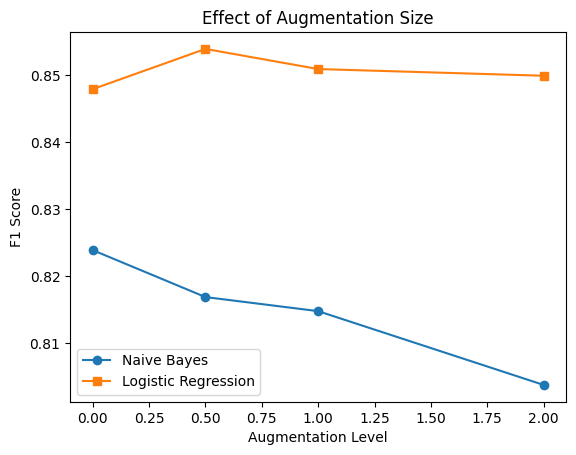

In [ ]:
sample_sizes = [0, 0.5, 1, 2]

# Naive Bayes
f1_scores_nb = [0.8239, 0.8169, 0.8148, 0.8038]

# Logistic Regression
f1_scores_lr = [0.8479, 0.8539,0.8509, 0.8499]

plt.figure()

plt.plot(sample_sizes, f1_scores_nb, marker='o', label='Naive Bayes')
plt.plot(sample_sizes, f1_scores_lr, marker='s', label='Logistic Regression')

plt.title("Effect of Augmentation Size")
plt.xlabel("Augmentation Level")
plt.ylabel("F1 Score")
plt.legend()  # zobrazí legendu

plt.show()

**Synonym replacement**

In [ ]:
import random
import re
from nltk.corpus import wordnet

def get_synonyms(word):
    synonyms = set()
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            synonyms.add(lemma.name())
    return list(synonyms)

def synonym_replacement(words, n=1):
    new_words = words.copy()
    random_words = list(set(words))
    random.shuffle(random_words)

    num_replaced = 0

    for word in random_words:
        synonyms = get_synonyms(word)

        if len(synonyms) > 0:
            synonym = random.choice(synonyms)
            new_words = [synonym if w == word else w for w in new_words]
            num_replaced += 1

        if num_replaced >= n:
            break

    return new_words


# 🔹 UPRAVENÁ VERZIA – po vetách
def eda_synonym(text):
    if not isinstance(text, str):
        return ""

    # rozdelenie na vety (zachová interpunkciu)
    sentences = re.split(r'([.!?])', text)

    new_sentences = []

    for i in range(0, len(sentences)-1, 2):
        sentence = sentences[i]
        punct = sentences[i+1]

        words = sentence.split()

        if len(words) < 2:
            new_sentences.append(sentence + punct)
            continue

        new_words = synonym_replacement(words, n=2)

        new_sentences.append(" ".join(new_words) + punct)

    return " ".join(new_sentences)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

nb_scores = {"acc": [], "prec": [], "rec": [], "f1": []}
lr_scores = {"acc": [], "prec": [], "rec": [], "f1": []}

for fold, (train_idx, test_idx) in enumerate(kf.split(df_small, df_small['label'])):
    print(f"\nFold {fold+1}")
    random.seed(42 + fold)
    np.random.seed(42 + fold)
    train_df = df_small.iloc[train_idx].copy()
    test_df = df_small.iloc[test_idx].copy()

    # 🔹 AUGMENTÁCIA LEN TRAIN
    sample_size = int(0.5 * len(train_df))
    aug_df = train_df.sample(sample_size, replace=True, random_state=42).copy()
    aug_df['text'] = aug_df['text'].apply(eda_synonym)

    train_aug = pd.concat([train_df, aug_df])

    # 🔹 TF-IDF
    vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')

    X_train = vectorizer.fit_transform(train_aug['text'])
    y_train = train_aug['label'].astype(int)

    X_test = vectorizer.transform(test_df['text'])
    y_test = test_df['label'].astype(int)

    # 🔹 MODELY
    nb = MultinomialNB()
    lr = LogisticRegression(max_iter=1000)

    nb.fit(X_train, y_train)
    lr.fit(X_train, y_train)

    y_pred_nb = nb.predict(X_test)
    y_pred_lr = lr.predict(X_test)

    # 🔹 METRIKY
    def compute_metrics(y_true, y_pred):
        return {
            "acc": accuracy_score(y_true, y_pred),
            "prec": precision_score(y_true, y_pred, average='weighted', zero_division=0),
            "rec": recall_score(y_true, y_pred, average='weighted', zero_division=0),
            "f1": f1_score(y_true, y_pred, average='weighted', zero_division=0),
        }

    nb_m = compute_metrics(y_test, y_pred_nb)
    lr_m = compute_metrics(y_test, y_pred_lr)

    for k in nb_scores:
        nb_scores[k].append(nb_m[k])
        lr_scores[k].append(lr_m[k])

# 🔹 VÝSLEDKY
print("\nNaive Bayes:")
for k in nb_scores:
    print(f"{k.upper()}: {nb_scores[k]}")
    print(f"Average {k.upper()}: {np.mean(nb_scores[k])}")

print("\nLogistic Regression:")
for k in lr_scores:
    print(f"{k.upper()}: {lr_scores[k]}")
    print(f"Average {k.upper()}: {np.mean(lr_scores[k])}")


Fold 1

Fold 2

Fold 3

Fold 4

Fold 5

Naive Bayes:
ACC: [0.795, 0.84, 0.81, 0.815, 0.825]
Average ACC: 0.817
PREC: [0.7950295029502951, 0.84, 0.8111200321156161, 0.8152837553798418, 0.8266003416742036]
Average PREC: 0.8176067264239913
REC: [0.795, 0.84, 0.81, 0.815, 0.825]
Average REC: 0.817
F1: [0.7949948748718718, 0.84, 0.8098288459613653, 0.8149583656322673, 0.8247853620685339]
Average F1: 0.8169134897068077

Logistic Regression:
ACC: [0.855, 0.855, 0.815, 0.865, 0.87]
Average ACC: 0.852
PREC: [0.855035503550355, 0.855035503550355, 0.8150315031503151, 0.8659147869674186, 0.8713368125250903]
Average PREC: 0.8524708219487067
REC: [0.855, 0.855, 0.815, 0.865, 0.87]
Average REC: 0.852
F1: [0.8549963749093727, 0.8549963749093727, 0.8149953748843721, 0.8649155722326455, 0.8698828946051447]
Average F1: 0.8519573183081816


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

nb_scores = {"acc": [], "prec": [], "rec": [], "f1": []}
lr_scores = {"acc": [], "prec": [], "rec": [], "f1": []}

for fold, (train_idx, test_idx) in enumerate(kf.split(df_small, df_small['label'])):
    print(f"\nFold {fold+1}")
    random.seed(42 + fold)
    np.random.seed(42 + fold)
    train_df = df_small.iloc[train_idx].copy()
    test_df = df_small.iloc[test_idx].copy()

    # 🔹 AUGMENTÁCIA LEN TRAIN
    sample_size = int(1 * len(train_df))
    aug_df = train_df.sample(sample_size, replace=True, random_state=42).copy()
    aug_df['text'] = aug_df['text'].apply(eda_synonym)

    train_aug = pd.concat([train_df, aug_df])

    # 🔹 TF-IDF
    vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')

    X_train = vectorizer.fit_transform(train_aug['text'])
    y_train = train_aug['label'].astype(int)

    X_test = vectorizer.transform(test_df['text'])
    y_test = test_df['label'].astype(int)

    # 🔹 MODELY
    nb = MultinomialNB()
    lr = LogisticRegression(max_iter=1000)

    nb.fit(X_train, y_train)
    lr.fit(X_train, y_train)

    y_pred_nb = nb.predict(X_test)
    y_pred_lr = lr.predict(X_test)

    # 🔹 METRIKY
    def compute_metrics(y_true, y_pred):
        return {
            "acc": accuracy_score(y_true, y_pred),
            "prec": precision_score(y_true, y_pred, average='weighted', zero_division=0),
            "rec": recall_score(y_true, y_pred, average='weighted', zero_division=0),
            "f1": f1_score(y_true, y_pred, average='weighted', zero_division=0),
        }

    nb_m = compute_metrics(y_test, y_pred_nb)
    lr_m = compute_metrics(y_test, y_pred_lr)

    for k in nb_scores:
        nb_scores[k].append(nb_m[k])
        lr_scores[k].append(lr_m[k])

# 🔹 VÝSLEDKY
print("\nNaive Bayes:")
for k in nb_scores:
    print(f"{k.upper()}: {nb_scores[k]}")
    print(f"Average {k.upper()}: {np.mean(nb_scores[k])}")

print("\nLogistic Regression:")
for k in lr_scores:
    print(f"{k.upper()}: {lr_scores[k]}")
    print(f"Average {k.upper()}: {np.mean(lr_scores[k])}")


Fold 1

Fold 2

Fold 3

Fold 4

Fold 5

Naive Bayes:
ACC: [0.8, 0.82, 0.815, 0.81, 0.805]
Average ACC: 0.8099999999999999
PREC: [0.8001200480192077, 0.8205128205128206, 0.8157894736842105, 0.810124049619848, 0.8087357019941289]
Average PREC: 0.8110564187660432
REC: [0.8, 0.82, 0.815, 0.81, 0.805]
Average REC: 0.8099999999999999
F1: [0.7999799979998001, 0.8199279711884754, 0.8148843026891808, 0.80998099809981, 0.8044083352140224]
Average F1: 0.8098363210382578

Logistic Regression:
ACC: [0.865, 0.855, 0.825, 0.87, 0.855]
Average ACC: 0.8539999999999999
PREC: [0.8650365036503651, 0.855035503550355, 0.825032503250325, 0.8705929487179486, 0.8567480655210531]
Average PREC: 0.8544891049380094
REC: [0.865, 0.855, 0.825, 0.87, 0.855]
Average REC: 0.8539999999999999
F1: [0.8649966249156228, 0.8549963749093727, 0.8249956248906223, 0.8699479791916767, 0.8548221571424997]
Average F1: 0.8539517522099589


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

nb_scores = {"acc": [], "prec": [], "rec": [], "f1": []}
lr_scores = {"acc": [], "prec": [], "rec": [], "f1": []}

for fold, (train_idx, test_idx) in enumerate(kf.split(df_small, df_small['label'])):
    print(f"\nFold {fold+1}")
    random.seed(42 + fold)
    np.random.seed(42 + fold)
    train_df = df_small.iloc[train_idx].copy()
    test_df = df_small.iloc[test_idx].copy()

    # 🔹 AUGMENTÁCIA LEN TRAIN
    sample_size = int(2 * len(train_df))
    aug_df = train_df.sample(sample_size, replace=True, random_state=42).copy()
    aug_df['text'] = aug_df['text'].apply(eda_synonym)

    train_aug = pd.concat([train_df, aug_df])

    # 🔹 TF-IDF
    vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')

    X_train = vectorizer.fit_transform(train_aug['text'])
    y_train = train_aug['label'].astype(int)

    X_test = vectorizer.transform(test_df['text'])
    y_test = test_df['label'].astype(int)

    # 🔹 MODELY
    nb = MultinomialNB()
    lr = LogisticRegression(max_iter=1000)

    nb.fit(X_train, y_train)
    lr.fit(X_train, y_train)

    y_pred_nb = nb.predict(X_test)
    y_pred_lr = lr.predict(X_test)

    # 🔹 METRIKY
    def compute_metrics(y_true, y_pred):
        return {
            "acc": accuracy_score(y_true, y_pred),
            "prec": precision_score(y_true, y_pred, average='weighted', zero_division=0),
            "rec": recall_score(y_true, y_pred, average='weighted', zero_division=0),
            "f1": f1_score(y_true, y_pred, average='weighted', zero_division=0),
        }

    nb_m = compute_metrics(y_test, y_pred_nb)
    lr_m = compute_metrics(y_test, y_pred_lr)

    for k in nb_scores:
        nb_scores[k].append(nb_m[k])
        lr_scores[k].append(lr_m[k])

# 🔹 VÝSLEDKY
print("\nNaive Bayes:")
for k in nb_scores:
    print(f"{k.upper()}: {nb_scores[k]}")
    print(f"Average {k.upper()}: {np.mean(nb_scores[k])}")

print("\nLogistic Regression:")
for k in lr_scores:
    print(f"{k.upper()}: {lr_scores[k]}")
    print(f"Average {k.upper()}: {np.mean(lr_scores[k])}")


Fold 1

Fold 2

Fold 3

Fold 4

Fold 5

Naive Bayes:
ACC: [0.79, 0.815, 0.8, 0.8, 0.835]
Average ACC: 0.808
PREC: [0.7910477719791248, 0.8157894736842105, 0.8019323671497586, 0.8, 0.8366495829564867]
Average PREC: 0.8090838391539161
REC: [0.79, 0.815, 0.8, 0.8, 0.835]
Average REC: 0.808
F1: [0.7898108297467721, 0.8148843026891808, 0.7996794871794871, 0.8, 0.8347976270931892]
Average F1: 0.8078344493417259

Logistic Regression:
ACC: [0.855, 0.865, 0.815, 0.86, 0.86]
Average ACC: 0.851
PREC: [0.8553197878090282, 0.8650365036503651, 0.8150315031503151, 0.86, 0.8623188405797102]
Average PREC: 0.8515413270378837
REC: [0.855, 0.865, 0.815, 0.86, 0.86]
Average REC: 0.851
F1: [0.854967367657723, 0.8649966249156228, 0.8149953748843721, 0.86, 0.859775641025641]
Average F1: 0.8509470016966716


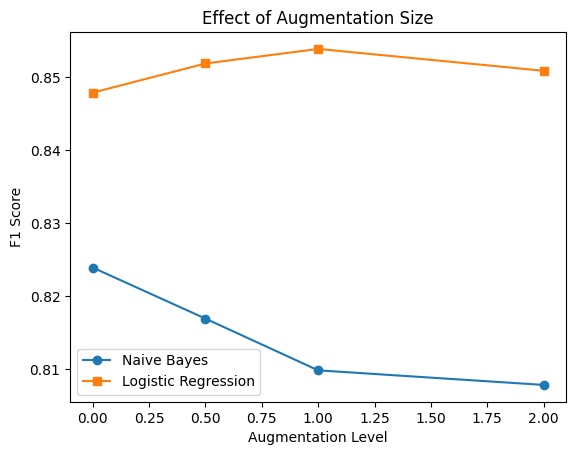

In [ ]:
sample_sizes = [0, 0.5, 1, 2]

# Naive Bayes
f1_scores_nb = [0.8239, 0.8169, 0.8098, 0.8078]

# Logistic Regression
f1_scores_lr = [0.8479, 0.8519,0.8539, 0.8509]

plt.figure()

plt.plot(sample_sizes, f1_scores_nb, marker='o', label='Naive Bayes')
plt.plot(sample_sizes, f1_scores_lr, marker='s', label='Logistic Regression')

plt.title("Effect of Augmentation Size")
plt.xlabel("Augmentation Level")
plt.ylabel("F1 Score")
plt.legend()  # zobrazí legendu

plt.show()

**Random Deletion**

In [ ]:
import random
import re

def random_deletion(words, p=0.1):
    if len(words) == 1:
        return words

    new_words = []

    for word in words:
        r = random.uniform(0, 1)
        if r > p:
            new_words.append(word)

    # ak sa vymazalo všetko → zachovať aspoň jedno slovo
    if len(new_words) == 0:
        return [random.choice(words)]

    return new_words


# 🔹 UPRAVENÁ VERZIA – po vetách
def eda_random_deletion(text):
    if not isinstance(text, str):
        return ""

    # rozdelenie na vety
    sentences = re.split(r'([.!?])', text)

    new_sentences = []

    for i in range(0, len(sentences)-1, 2):
        sentence = sentences[i]
        punct = sentences[i+1]

        words = sentence.split()

        if len(words) == 0:
            new_sentences.append(sentence + punct)
            continue

        new_words = random_deletion(words, p=0.05)

        if len(new_words) == 0:
            new_sentences.append(sentence + punct)
            continue

        new_sentences.append(" ".join(new_words) + punct)

    return " ".join(new_sentences)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

nb_scores = {"acc": [], "prec": [], "rec": [], "f1": []}
lr_scores = {"acc": [], "prec": [], "rec": [], "f1": []}

for fold, (train_idx, test_idx) in enumerate(kf.split(df_small, df_small['label'])):
    print(f"\nFold {fold+1}")
    random.seed(42 + fold)
    np.random.seed(42 + fold)
    train_df = df_small.iloc[train_idx].copy()
    test_df = df_small.iloc[test_idx].copy()

    # 🔹 AUGMENTÁCIA LEN TRAIN
    sample_size = int(0.5 * len(train_df))
    aug_df = train_df.sample(sample_size, replace=True, random_state=42).copy()
    aug_df['text'] = aug_df['text'].apply(eda_random_deletion)

    train_aug = pd.concat([train_df, aug_df])

    # 🔹 TF-IDF
    vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')

    X_train = vectorizer.fit_transform(train_aug['text'])
    y_train = train_aug['label'].astype(int)

    X_test = vectorizer.transform(test_df['text'])
    y_test = test_df['label'].astype(int)

    # 🔹 MODELY
    nb = MultinomialNB()
    lr = LogisticRegression(max_iter=1000)

    nb.fit(X_train, y_train)
    lr.fit(X_train, y_train)

    y_pred_nb = nb.predict(X_test)
    y_pred_lr = lr.predict(X_test)

    # 🔹 METRIKY
    def compute_metrics(y_true, y_pred):
        return {
            "acc": accuracy_score(y_true, y_pred),
            "prec": precision_score(y_true, y_pred, average='weighted', zero_division=0),
            "rec": recall_score(y_true, y_pred, average='weighted', zero_division=0),
            "f1": f1_score(y_true, y_pred, average='weighted', zero_division=0),
        }

    nb_m = compute_metrics(y_test, y_pred_nb)
    lr_m = compute_metrics(y_test, y_pred_lr)

    for k in nb_scores:
        nb_scores[k].append(nb_m[k])
        lr_scores[k].append(lr_m[k])

# 🔹 VÝSLEDKY
print("\nNaive Bayes:")
for k in nb_scores:
    print(f"{k.upper()}: {nb_scores[k]}")
    print(f"Average {k.upper()}: {np.mean(nb_scores[k])}")

print("\nLogistic Regression:")
for k in lr_scores:
    print(f"{k.upper()}: {lr_scores[k]}")
    print(f"Average {k.upper()}: {np.mean(lr_scores[k])}")



Fold 1

Fold 2

Fold 3

Fold 4

Fold 5

Naive Bayes:
ACC: [0.795, 0.845, 0.805, 0.815, 0.815]
Average ACC: 0.8150000000000001
PREC: [0.7950295029502951, 0.845034503450345, 0.8057644110275689, 0.8157894736842105, 0.8165511003919204]
Average PREC: 0.8156337983008679
REC: [0.795, 0.845, 0.805, 0.815, 0.815]
Average REC: 0.8150000000000001
F1: [0.7949948748718718, 0.8449961249031226, 0.804878048780488, 0.8148843026891808, 0.8147730970438788]
Average F1: 0.8149052896577084

Logistic Regression:
ACC: [0.855, 0.86, 0.815, 0.865, 0.86]
Average ACC: 0.851
PREC: [0.855035503550355, 0.86, 0.8150315031503151, 0.8659147869674186, 0.8613006824568447]
Average PREC: 0.8514564952249867
REC: [0.855, 0.86, 0.815, 0.865, 0.86]
Average REC: 0.851
F1: [0.8549963749093727, 0.86, 0.8149953748843721, 0.8649155722326455, 0.859873886497848]
Average F1: 0.8509562417048476


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

nb_scores = {"acc": [], "prec": [], "rec": [], "f1": []}
lr_scores = {"acc": [], "prec": [], "rec": [], "f1": []}

for fold, (train_idx, test_idx) in enumerate(kf.split(df_small, df_small['label'])):
    print(f"\nFold {fold+1}")
    random.seed(42 + fold)
    np.random.seed(42 + fold)
    train_df = df_small.iloc[train_idx].copy()
    test_df = df_small.iloc[test_idx].copy()

    # 🔹 AUGMENTÁCIA LEN TRAIN
    sample_size = int(1 * len(train_df))
    aug_df = train_df.sample(sample_size, replace=True, random_state=42).copy()
    aug_df['text'] = aug_df['text'].apply(eda_random_deletion)

    train_aug = pd.concat([train_df, aug_df])

    # 🔹 TF-IDF
    vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')

    X_train = vectorizer.fit_transform(train_aug['text'])
    y_train = train_aug['label'].astype(int)

    X_test = vectorizer.transform(test_df['text'])
    y_test = test_df['label'].astype(int)

    # 🔹 MODELY
    nb = MultinomialNB()
    lr = LogisticRegression(max_iter=1000)

    nb.fit(X_train, y_train)
    lr.fit(X_train, y_train)

    y_pred_nb = nb.predict(X_test)
    y_pred_lr = lr.predict(X_test)

    # 🔹 METRIKY
    def compute_metrics(y_true, y_pred):
        return {
            "acc": accuracy_score(y_true, y_pred),
            "prec": precision_score(y_true, y_pred, average='weighted', zero_division=0),
            "rec": recall_score(y_true, y_pred, average='weighted', zero_division=0),
            "f1": f1_score(y_true, y_pred, average='weighted', zero_division=0),
        }

    nb_m = compute_metrics(y_test, y_pred_nb)
    lr_m = compute_metrics(y_test, y_pred_lr)

    for k in nb_scores:
        nb_scores[k].append(nb_m[k])
        lr_scores[k].append(lr_m[k])

# 🔹 VÝSLEDKY
print("\nNaive Bayes:")
for k in nb_scores:
    print(f"{k.upper()}: {nb_scores[k]}")
    print(f"Average {k.upper()}: {np.mean(nb_scores[k])}")

print("\nLogistic Regression:")
for k in lr_scores:
    print(f"{k.upper()}: {lr_scores[k]}")
    print(f"Average {k.upper()}: {np.mean(lr_scores[k])}")


Fold 1

Fold 2

Fold 3

Fold 4

Fold 5

Naive Bayes:
ACC: [0.815, 0.82, 0.815, 0.805, 0.805]
Average ACC: 0.8119999999999999
PREC: [0.8152837553798418, 0.8205128205128206, 0.8152837553798418, 0.8052747472725453, 0.8102431085342283]
Average PREC: 0.8133196374158557
REC: [0.815, 0.82, 0.815, 0.805, 0.805]
Average REC: 0.8119999999999999
F1: [0.8149583656322673, 0.8199279711884754, 0.8149583656322673, 0.8049561151259033, 0.8041726293590421]
Average F1: 0.811794689387591

Logistic Regression:
ACC: [0.865, 0.86, 0.82, 0.87, 0.855]
Average ACC: 0.8539999999999999
PREC: [0.8653287959163246, 0.86, 0.8201280512204883, 0.8705929487179486, 0.8593481121571008]
Average PREC: 0.8550795816023724
REC: [0.865, 0.86, 0.82, 0.87, 0.855]
Average REC: 0.8539999999999999
F1: [0.8649696181640869, 0.86, 0.8199819981998201, 0.8699479791916767, 0.8545600441335038]
Average F1: 0.8538919279378175


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

nb_scores = {"acc": [], "prec": [], "rec": [], "f1": []}
lr_scores = {"acc": [], "prec": [], "rec": [], "f1": []}

for fold, (train_idx, test_idx) in enumerate(kf.split(df_small, df_small['label'])):
    print(f"\nFold {fold+1}")
    random.seed(42 + fold)
    np.random.seed(42 + fold)
    train_df = df_small.iloc[train_idx].copy()
    test_df = df_small.iloc[test_idx].copy()

    # 🔹 AUGMENTÁCIA LEN TRAIN
    sample_size = int(2 * len(train_df))
    aug_df = train_df.sample(sample_size, replace=True, random_state=42).copy()
    aug_df['text'] = aug_df['text'].apply(eda_random_deletion)

    train_aug = pd.concat([train_df, aug_df])

    # 🔹 TF-IDF
    vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')

    X_train = vectorizer.fit_transform(train_aug['text'])
    y_train = train_aug['label'].astype(int)

    X_test = vectorizer.transform(test_df['text'])
    y_test = test_df['label'].astype(int)

    # 🔹 MODELY
    nb = MultinomialNB()
    lr = LogisticRegression(max_iter=1000)

    nb.fit(X_train, y_train)
    lr.fit(X_train, y_train)

    y_pred_nb = nb.predict(X_test)
    y_pred_lr = lr.predict(X_test)

    # 🔹 METRIKY
    def compute_metrics(y_true, y_pred):
        return {
            "acc": accuracy_score(y_true, y_pred),
            "prec": precision_score(y_true, y_pred, average='weighted', zero_division=0),
            "rec": recall_score(y_true, y_pred, average='weighted', zero_division=0),
            "f1": f1_score(y_true, y_pred, average='weighted', zero_division=0),
        }

    nb_m = compute_metrics(y_test, y_pred_nb)
    lr_m = compute_metrics(y_test, y_pred_lr)

    for k in nb_scores:
        nb_scores[k].append(nb_m[k])
        lr_scores[k].append(lr_m[k])

# 🔹 VÝSLEDKY
print("\nNaive Bayes:")
for k in nb_scores:
    print(f"{k.upper()}: {nb_scores[k]}")
    print(f"Average {k.upper()}: {np.mean(nb_scores[k])}")

print("\nLogistic Regression:")
for k in lr_scores:
    print(f"{k.upper()}: {lr_scores[k]}")
    print(f"Average {k.upper()}: {np.mean(lr_scores[k])}")


Fold 1

Fold 2

Fold 3

Fold 4

Fold 5

Naive Bayes:
ACC: [0.795, 0.81, 0.815, 0.81, 0.83]
Average ACC: 0.8119999999999999
PREC: [0.7950295029502951, 0.8111200321156161, 0.8157894736842105, 0.810124049619848, 0.8321256038647342]
Average PREC: 0.8128377324469408
REC: [0.795, 0.81, 0.815, 0.81, 0.83]
Average REC: 0.8119999999999999
F1: [0.7949948748718718, 0.8098288459613653, 0.8148843026891808, 0.80998099809981, 0.8297275641025641]
Average F1: 0.8118833171449584

Logistic Regression:
ACC: [0.855, 0.865, 0.82, 0.865, 0.86]
Average ACC: 0.8530000000000001
PREC: [0.855035503550355, 0.8650365036503651, 0.8201280512204883, 0.8653287959163246, 0.8623188405797102]
Average PREC: 0.8535695389834487
REC: [0.855, 0.865, 0.82, 0.865, 0.86]
Average REC: 0.8530000000000001
F1: [0.8549963749093727, 0.8649966249156228, 0.8199819981998201, 0.8649696181640869, 0.859775641025641]
Average F1: 0.8529440514429087


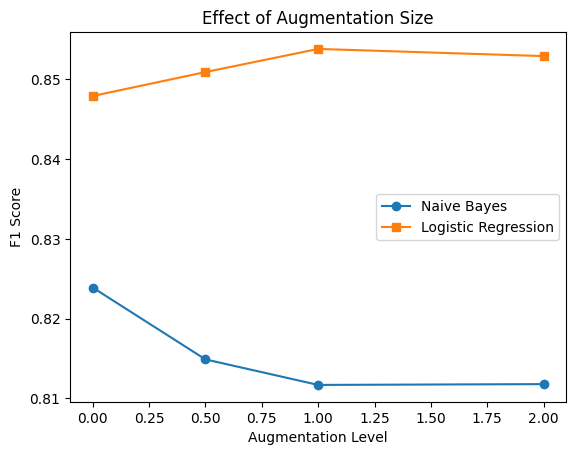

In [ ]:
sample_sizes = [0, 0.5, 1, 2]

# Naive Bayes
f1_scores_nb = [0.8239, 0.8149, 0.8117, 0.8118]

# Logistic Regression
f1_scores_lr = [0.8479, 0.8509,0.8538, 0.8529]

plt.figure()

plt.plot(sample_sizes, f1_scores_nb, marker='o', label='Naive Bayes')
plt.plot(sample_sizes, f1_scores_lr, marker='s', label='Logistic Regression')

plt.title("Effect of Augmentation Size")
plt.xlabel("Augmentation Level")
plt.ylabel("F1 Score")
plt.legend()  # zobrazí legendu

plt.show()

**Random swap**

In [ ]:
import random
import re

def random_swap(words, n=1):
    new_words = words.copy()
    length = len(new_words)

    if length < 2:
        return new_words

    for _ in range(n):
        idx1, idx2 = random.sample(range(length), 2)
        new_words[idx1], new_words[idx2] = new_words[idx2], new_words[idx1]

    return new_words


def eda_random_swap(text):
    if not isinstance(text, str):
        return ""

    # rozdelenie na vety (zachová interpunkciu)
    sentences = re.split(r'([.!?])', text)

    new_sentences = []

    for i in range(0, len(sentences)-1, 2):
        sentence = sentences[i].strip()
        punct = sentences[i+1]

        words = sentence.split()

        # DEBUG kontrola
        if len(words) < 2:
            new_sentences.append(sentence + punct)
            continue

        swapped_words = random_swap(words, n=2)

        # bezpečnostná kontrola
        if len(swapped_words) != len(words):
            print("ERROR: length mismatch")

        new_sentences.append(" ".join(swapped_words) + punct)

    return " ".join(new_sentences)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

nb_scores = {"acc": [], "prec": [], "rec": [], "f1": []}
lr_scores = {"acc": [], "prec": [], "rec": [], "f1": []}

for fold, (train_idx, test_idx) in enumerate(kf.split(df_small, df_small['label'])):
    print(f"\nFold {fold+1}")
    random.seed(42 + fold)
    np.random.seed(42 + fold)
    train_df = df_small.iloc[train_idx].copy()
    test_df = df_small.iloc[test_idx].copy()

    # 🔹 AUGMENTÁCIA LEN TRAIN
    sample_size = int(0.5 * len(train_df))
    aug_df = train_df.sample(sample_size, replace=True, random_state=42).copy()
    aug_df['text'] = aug_df['text'].apply(eda_random_swap)

    train_aug = pd.concat([train_df, aug_df])

    # 🔹 TF-IDF
    vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')

    X_train = vectorizer.fit_transform(train_aug['text'])
    y_train = train_aug['label'].astype(int)

    X_test = vectorizer.transform(test_df['text'])
    y_test = test_df['label'].astype(int)

    # 🔹 MODELY
    nb = MultinomialNB()
    lr = LogisticRegression(max_iter=1000)

    nb.fit(X_train, y_train)
    lr.fit(X_train, y_train)

    y_pred_nb = nb.predict(X_test)
    y_pred_lr = lr.predict(X_test)

    # 🔹 METRIKY
    def compute_metrics(y_true, y_pred):
        return {
            "acc": accuracy_score(y_true, y_pred),
            "prec": precision_score(y_true, y_pred, average='weighted', zero_division=0),
            "rec": recall_score(y_true, y_pred, average='weighted', zero_division=0),
            "f1": f1_score(y_true, y_pred, average='weighted', zero_division=0),
        }

    nb_m = compute_metrics(y_test, y_pred_nb)
    lr_m = compute_metrics(y_test, y_pred_lr)

    for k in nb_scores:
        nb_scores[k].append(nb_m[k])
        lr_scores[k].append(lr_m[k])

# 🔹 VÝSLEDKY
print("\nNaive Bayes:")
for k in nb_scores:
    print(f"{k.upper()}: {nb_scores[k]}")
    print(f"Average {k.upper()}: {np.mean(nb_scores[k])}")

print("\nLogistic Regression:")
for k in lr_scores:
    print(f"{k.upper()}: {lr_scores[k]}")
    print(f"Average {k.upper()}: {np.mean(lr_scores[k])}")


Fold 1

Fold 2

Fold 3

Fold 4

Fold 5

Naive Bayes:
ACC: [0.795, 0.84, 0.815, 0.815, 0.815]
Average ACC: 0.8160000000000001
PREC: [0.7950295029502951, 0.84, 0.8152837553798418, 0.8157894736842105, 0.8165511003919204]
Average PREC: 0.8165307664812536
REC: [0.795, 0.84, 0.815, 0.815, 0.815]
Average REC: 0.8160000000000001
F1: [0.7949948748718718, 0.84, 0.8149583656322673, 0.8148843026891808, 0.8147730970438788]
Average F1: 0.8159221280474396

Logistic Regression:
ACC: [0.855, 0.865, 0.815, 0.87, 0.865]
Average ACC: 0.8540000000000001
PREC: [0.855035503550355, 0.8650365036503651, 0.8150315031503151, 0.8713368125250903, 0.8667973068033363]
Average PREC: 0.8546475259358923
REC: [0.855, 0.865, 0.815, 0.87, 0.865]
Average REC: 0.8540000000000001
F1: [0.8549963749093727, 0.8649966249156228, 0.8149953748843721, 0.8698828946051447, 0.8648344221671548]
Average F1: 0.8539411382963336


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

nb_scores = {"acc": [], "prec": [], "rec": [], "f1": []}
lr_scores = {"acc": [], "prec": [], "rec": [], "f1": []}

for fold, (train_idx, test_idx) in enumerate(kf.split(df_small, df_small['label'])):
    print(f"\nFold {fold+1}")
    random.seed(42 + fold)
    np.random.seed(42 + fold)
    train_df = df_small.iloc[train_idx].copy()
    test_df = df_small.iloc[test_idx].copy()

    # 🔹 AUGMENTÁCIA LEN TRAIN
    sample_size = int(1 * len(train_df))
    aug_df = train_df.sample(sample_size, replace=True, random_state=42).copy()
    aug_df['text'] = aug_df['text'].apply(eda_random_swap)

    train_aug = pd.concat([train_df, aug_df])

    # 🔹 TF-IDF
    vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')

    X_train = vectorizer.fit_transform(train_aug['text'])
    y_train = train_aug['label'].astype(int)

    X_test = vectorizer.transform(test_df['text'])
    y_test = test_df['label'].astype(int)

    # 🔹 MODELY
    nb = MultinomialNB()
    lr = LogisticRegression(max_iter=1000)

    nb.fit(X_train, y_train)
    lr.fit(X_train, y_train)

    y_pred_nb = nb.predict(X_test)
    y_pred_lr = lr.predict(X_test)

    # 🔹 METRIKY
    def compute_metrics(y_true, y_pred):
        return {
            "acc": accuracy_score(y_true, y_pred),
            "prec": precision_score(y_true, y_pred, average='weighted', zero_division=0),
            "rec": recall_score(y_true, y_pred, average='weighted', zero_division=0),
            "f1": f1_score(y_true, y_pred, average='weighted', zero_division=0),
        }

    nb_m = compute_metrics(y_test, y_pred_nb)
    lr_m = compute_metrics(y_test, y_pred_lr)

    for k in nb_scores:
        nb_scores[k].append(nb_m[k])
        lr_scores[k].append(lr_m[k])

# 🔹 VÝSLEDKY
print("\nNaive Bayes:")
for k in nb_scores:
    print(f"{k.upper()}: {nb_scores[k]}")
    print(f"Average {k.upper()}: {np.mean(nb_scores[k])}")

print("\nLogistic Regression:")
for k in lr_scores:
    print(f"{k.upper()}: {lr_scores[k]}")
    print(f"Average {k.upper()}: {np.mean(lr_scores[k])}")


Fold 1

Fold 2

Fold 3

Fold 4

Fold 5

Naive Bayes:
ACC: [0.81, 0.82, 0.81, 0.8, 0.805]
Average ACC: 0.8089999999999999
PREC: [0.810124049619848, 0.8205128205128206, 0.810124049619848, 0.8001200480192077, 0.8102431085342283]
Average PREC: 0.8102248152611905
REC: [0.81, 0.82, 0.81, 0.8, 0.805]
Average REC: 0.8089999999999999
F1: [0.80998099809981, 0.8199279711884754, 0.80998099809981, 0.7999799979998001, 0.8041726293590421]
Average F1: 0.8088085189493874

Logistic Regression:
ACC: [0.855, 0.865, 0.82, 0.87, 0.85]
Average ACC: 0.852
PREC: [0.855035503550355, 0.8650365036503651, 0.8201280512204883, 0.8705929487179486, 0.8535353535353536]
Average PREC: 0.8528656721349022
REC: [0.855, 0.865, 0.82, 0.87, 0.85]
Average REC: 0.852
F1: [0.8549963749093727, 0.8649966249156228, 0.8199819981998201, 0.8699479791916767, 0.8496240601503758]
Average F1: 0.8519094074733736


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

nb_scores = {"acc": [], "prec": [], "rec": [], "f1": []}
lr_scores = {"acc": [], "prec": [], "rec": [], "f1": []}

for fold, (train_idx, test_idx) in enumerate(kf.split(df_small, df_small['label'])):
    print(f"\nFold {fold+1}")
    random.seed(42 + fold)
    np.random.seed(42 + fold)
    train_df = df_small.iloc[train_idx].copy()
    test_df = df_small.iloc[test_idx].copy()

    # 🔹 AUGMENTÁCIA LEN TRAIN
    sample_size = int(2 * len(train_df))
    aug_df = train_df.sample(sample_size, replace=True, random_state=42).copy()
    aug_df['text'] = aug_df['text'].apply(eda_random_swap)

    train_aug = pd.concat([train_df, aug_df])

    # 🔹 TF-IDF
    vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')

    X_train = vectorizer.fit_transform(train_aug['text'])
    y_train = train_aug['label'].astype(int)

    X_test = vectorizer.transform(test_df['text'])
    y_test = test_df['label'].astype(int)

    # 🔹 MODELY
    nb = MultinomialNB()
    lr = LogisticRegression(max_iter=1000)

    nb.fit(X_train, y_train)
    lr.fit(X_train, y_train)

    y_pred_nb = nb.predict(X_test)
    y_pred_lr = lr.predict(X_test)

    # 🔹 METRIKY
    def compute_metrics(y_true, y_pred):
        return {
            "acc": accuracy_score(y_true, y_pred),
            "prec": precision_score(y_true, y_pred, average='weighted', zero_division=0),
            "rec": recall_score(y_true, y_pred, average='weighted', zero_division=0),
            "f1": f1_score(y_true, y_pred, average='weighted', zero_division=0),
        }

    nb_m = compute_metrics(y_test, y_pred_nb)
    lr_m = compute_metrics(y_test, y_pred_lr)

    for k in nb_scores:
        nb_scores[k].append(nb_m[k])
        lr_scores[k].append(lr_m[k])

# 🔹 VÝSLEDKY
print("\nNaive Bayes:")
for k in nb_scores:
    print(f"{k.upper()}: {nb_scores[k]}")
    print(f"Average {k.upper()}: {np.mean(nb_scores[k])}")

print("\nLogistic Regression:")
for k in lr_scores:
    print(f"{k.upper()}: {lr_scores[k]}")
    print(f"Average {k.upper()}: {np.mean(lr_scores[k])}")


Fold 1

Fold 2

Fold 3

Fold 4

Fold 5

Naive Bayes:
ACC: [0.795, 0.81, 0.815, 0.815, 0.82]
Average ACC: 0.8109999999999999
PREC: [0.7952657391652487, 0.8111200321156161, 0.8157894736842105, 0.8152837553798418, 0.822061191626409]
Average PREC: 0.8119040383942652
REC: [0.795, 0.81, 0.815, 0.815, 0.82]
Average REC: 0.8109999999999999
F1: [0.7949538646195394, 0.8098288459613653, 0.8148843026891808, 0.8149583656322673, 0.8197115384615384]
Average F1: 0.8108673834727783

Logistic Regression:
ACC: [0.855, 0.865, 0.82, 0.86, 0.855]
Average ACC: 0.851
PREC: [0.855035503550355, 0.8650365036503651, 0.8201280512204883, 0.860576923076923, 0.8578989817521928]
Average PREC: 0.8517351926500648
REC: [0.855, 0.865, 0.82, 0.86, 0.855]
Average REC: 0.851
F1: [0.8549963749093727, 0.8649966249156228, 0.8199819981998201, 0.8599439775910364, 0.8547057792028858]
Average F1: 0.8509249509637475


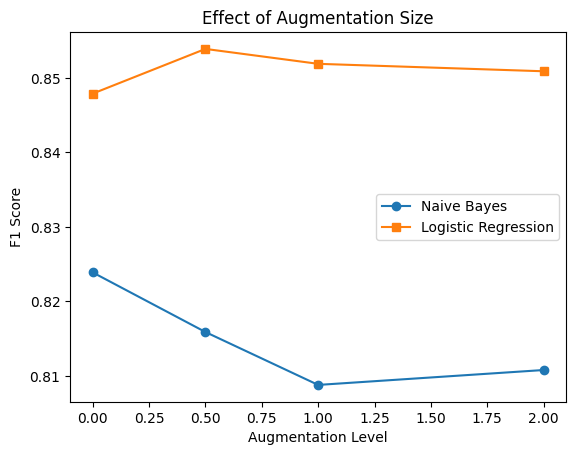

In [ ]:
sample_sizes = [0, 0.5, 1, 2]

# Naive Bayes
f1_scores_nb = [0.8239, 0.8159, 0.8088, 0.8108]

# Logistic Regression
f1_scores_lr = [0.8479, 0.8539,0.8519, 0.8509]

plt.figure()

plt.plot(sample_sizes, f1_scores_nb, marker='o', label='Naive Bayes')
plt.plot(sample_sizes, f1_scores_lr, marker='s', label='Logistic Regression')

plt.title("Effect of Augmentation Size")
plt.xlabel("Augmentation Level")
plt.ylabel("F1 Score")
plt.legend()  # zobrazí legendu

plt.show()

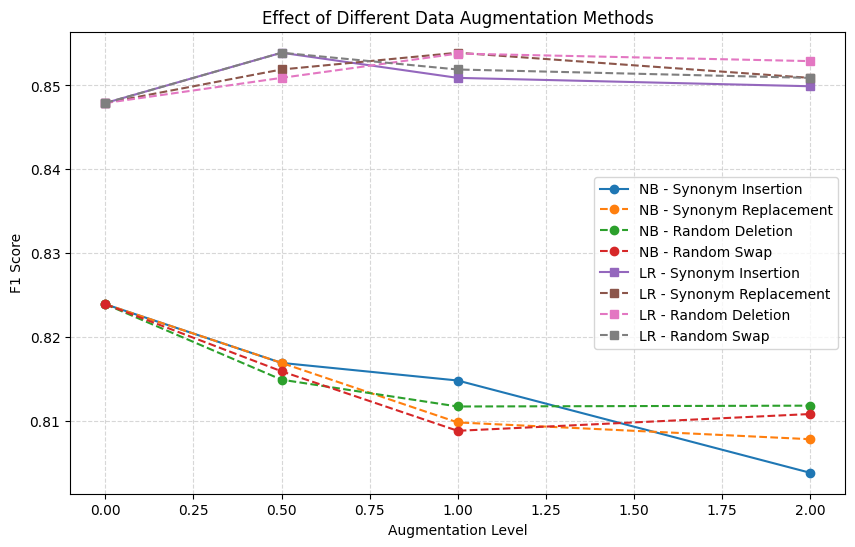

In [ ]:
import matplotlib.pyplot as plt

sample_sizes = [0, 0.5, 1, 2]

# 🔹 Random inserion
nb_eda_swap = [0.8239, 0.8169, 0.8148, 0.8038]
lr_eda_swap = [0.8479, 0.8539,0.8509, 0.8499]

# 🔹 Synonym replacement
nb_aug2 = [0.8239, 0.8169, 0.8098, 0.8078]
lr_aug2 = [0.8479, 0.8519,0.8539, 0.8509]

# 🔹 Random Deletion
nb_aug3 = [0.8239, 0.8149, 0.8117, 0.8118]
lr_aug3 = [0.8479, 0.8509,0.8538, 0.8529]

# 🔹 Random Swap
nb_aug4 = [0.8239, 0.8159, 0.8088, 0.8108]
lr_aug4 = [0.8479, 0.8539,0.8519, 0.8509]



plt.figure(figsize=(10,6))

# ===== NB =====
plt.plot(sample_sizes, nb_eda_swap, marker='o', label='NB - Random Insertion')
plt.plot(sample_sizes, nb_aug2, marker='o', linestyle='--', label='NB - Synonym Replacement')
plt.plot(sample_sizes, nb_aug3, marker='o', linestyle='--', label='NB - Random Deletion')
plt.plot(sample_sizes, nb_aug4, marker='o', linestyle='--', label='NB - Random Swap')


# ===== LR =====
plt.plot(sample_sizes, lr_eda_swap, marker='s', label='LR - Random Insertion')
plt.plot(sample_sizes, lr_aug2, marker='s', linestyle='--', label='LR - Synonym Replacement')
plt.plot(sample_sizes, lr_aug3, marker='s', linestyle='--', label='LR - Random Deletion')
plt.plot(sample_sizes, lr_aug4, marker='s', linestyle='--', label='LR - Random Swap')


plt.title("Effect of Different Data Augmentation Methods")
plt.xlabel("Augmentation Level")
plt.ylabel("F1 Score")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

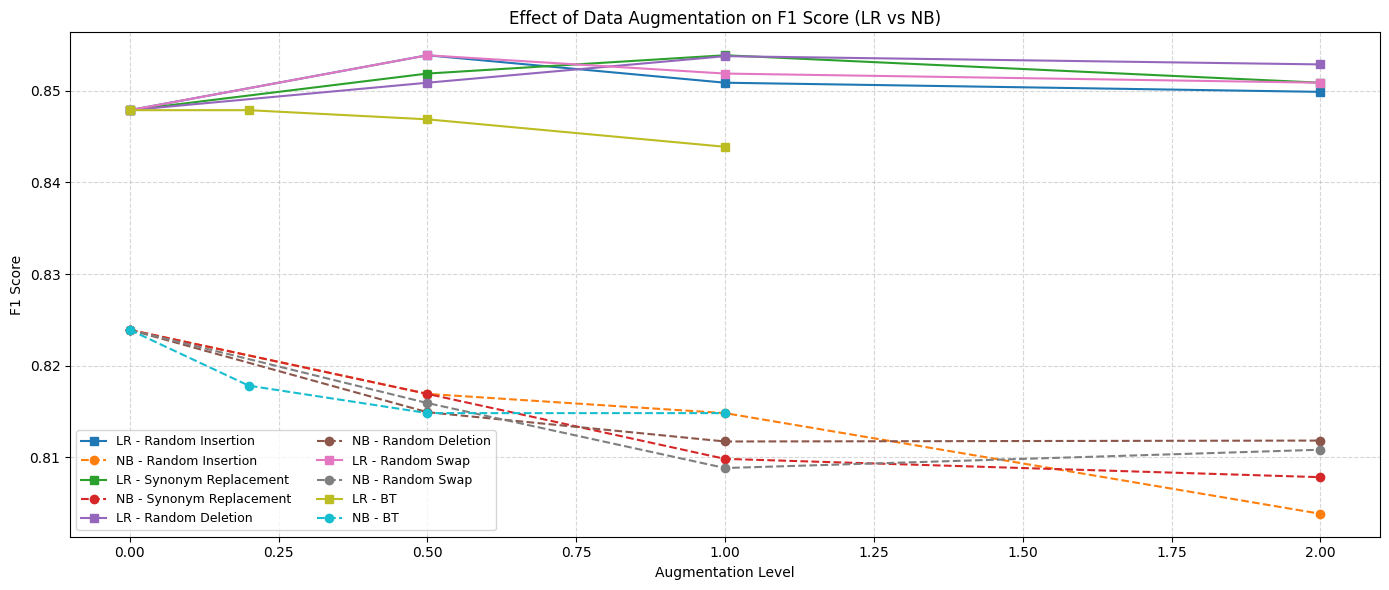

In [ ]:
import matplotlib.pyplot as plt

# =========================
# X AXES
# =========================
x1 = [0, 0.2, 0.5, 1]
x2 = [0, 0.5, 1, 2]

# =========================
# AUGMENTATIONS
# =========================

# Random Insertion
nb_aug1 = [0.8239, 0.8169, 0.8148, 0.8038]
lr_aug1 = [0.8479, 0.8539, 0.8509, 0.8499]

# Synonym Replacement
nb_aug2 = [0.8239, 0.8169, 0.8098, 0.8078]
lr_aug2 = [0.8479, 0.8519, 0.8539, 0.8509]

# Random Deletion
nb_aug3 = [0.8239, 0.8149, 0.8117, 0.8118]
lr_aug3 = [0.8479, 0.8509, 0.8538, 0.8529]

# Random Swap
nb_aug4 = [0.8239, 0.8159, 0.8088, 0.8108]
lr_aug4 = [0.8479, 0.8539, 0.8519, 0.8509]

# Random Swap
nb_aug5 = [0.8239, 0.8178, 0.8148, 0.8148]
lr_aug5 = [0.8479, 0.8479,0.8469, 0.8439]

# =========================
# PLOT
# =========================
plt.figure(figsize=(14, 6))

# -------- SET A (0–1) --------
plt.plot(x2, lr_aug1, marker='s', label='LR - Random Insertion')
plt.plot(x2, nb_aug1, marker='o', linestyle='--', label='NB - Random Insertion')

plt.plot(x2, lr_aug2, marker='s', label='LR - Synonym Replacement')
plt.plot(x2, nb_aug2, marker='o', linestyle='--', label='NB - Synonym Replacement')

# -------- SET B (0–2) --------
plt.plot(x2, lr_aug3, marker='s', label='LR - Random Deletion')
plt.plot(x2, nb_aug3, marker='o', linestyle='--', label='NB - Random Deletion')

plt.plot(x2, lr_aug4, marker='s', label='LR - Random Swap')
plt.plot(x2, nb_aug4, marker='o', linestyle='--', label='NB - Random Swap')

plt.plot(x1, lr_aug5, marker='s', label='LR - BT')
plt.plot(x1, nb_aug5, marker='o', linestyle='--', label='NB - BT')

# =========================
# STYLING
# =========================
plt.title("Effect of Data Augmentation on F1 Score (LR vs NB)")
plt.xlabel("Augmentation Level")
plt.ylabel("F1 Score")

plt.grid(True, linestyle='--', alpha=0.5)

plt.legend(ncol=2, fontsize=9)
plt.tight_layout()

plt.show()

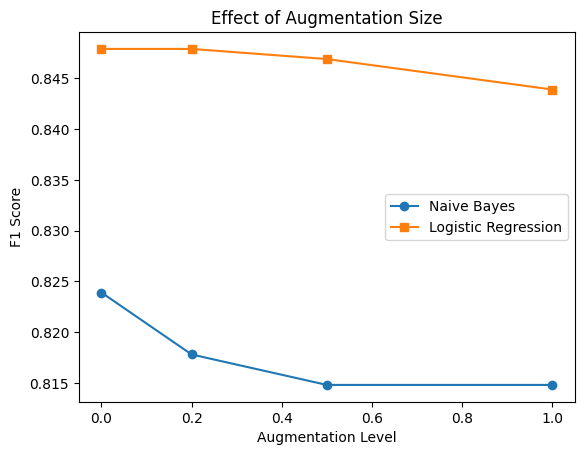

In [ ]:
sample_sizes = [0, 0.2, 0.5, 1]

# Naive Bayes
f1_scores_nb = [0.8239, 0.8178, 0.8148, 0.8148]

# Logistic Regression
f1_scores_lr = [0.8479, 0.8479,0.8469, 0.8439]

plt.figure()

plt.plot(sample_sizes, f1_scores_nb, marker='o', label='Naive Bayes')
plt.plot(sample_sizes, f1_scores_lr, marker='s', label='Logistic Regression')

plt.title("Effect of Augmentation Size")
plt.xlabel("Augmentation Level")
plt.ylabel("F1 Score")
plt.legend()  # zobrazí legendu

plt.show()